d:\Anaconda3\envs\rigqc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Harp line detected:  1
Total Harp events:  4613
No Harp line found. Please check recording.
Harp line detected:  1
Total Harp events:  284
No Harp line found. Please check recording.
No Harp line found. Please check recording.
Harp line detected:  1
Total Harp events:  4619
No Harp line found. Please check recording.
No Harp line found. Please check recording.
No Harp line found. Please check recording.
No Harp line found. Please check recording.
No Harp line found. Please check recording.
No Harp line found. Please check recording.
No Harp line found. Please check recording.
No Harp line found. Please check recording.


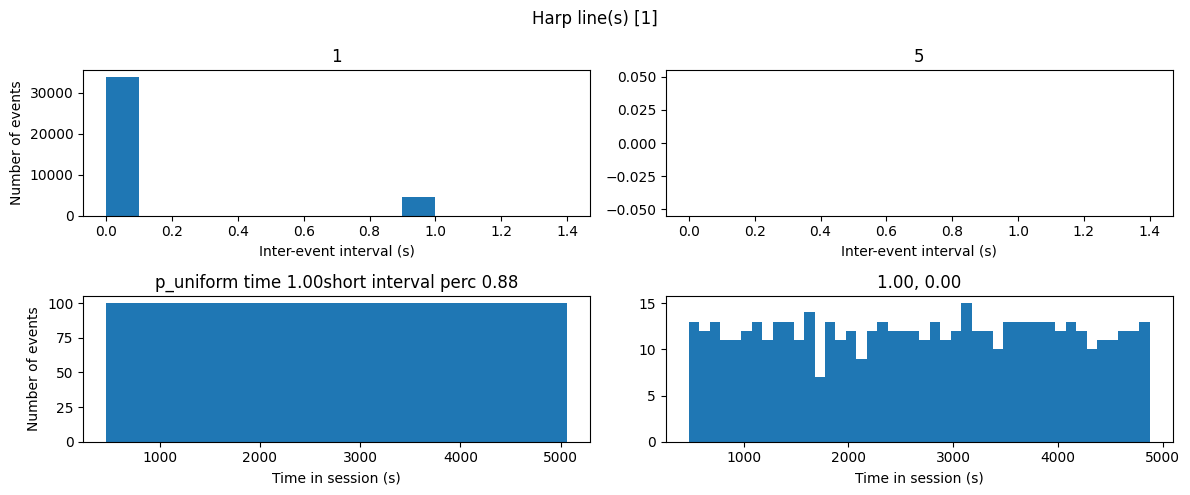

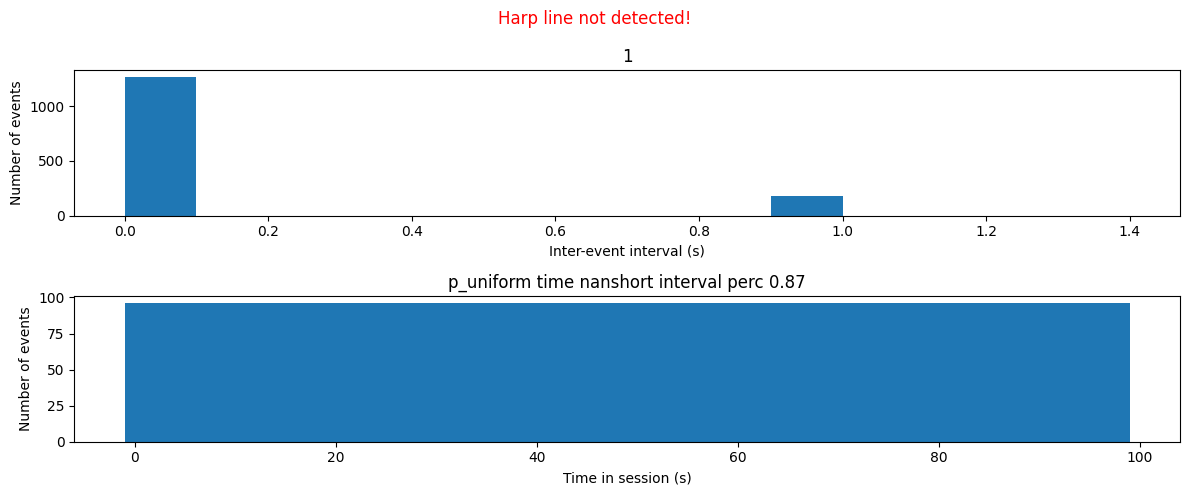

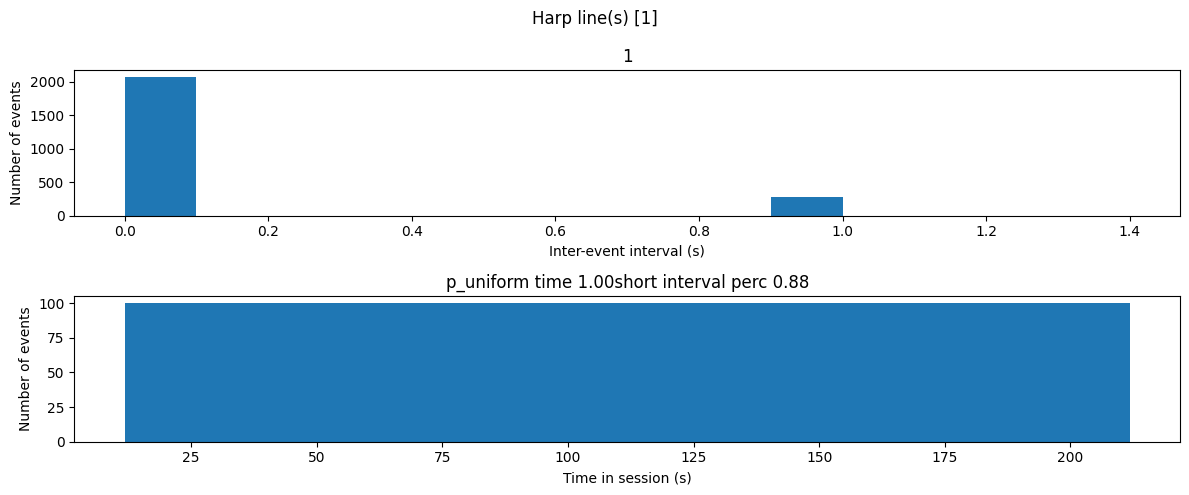

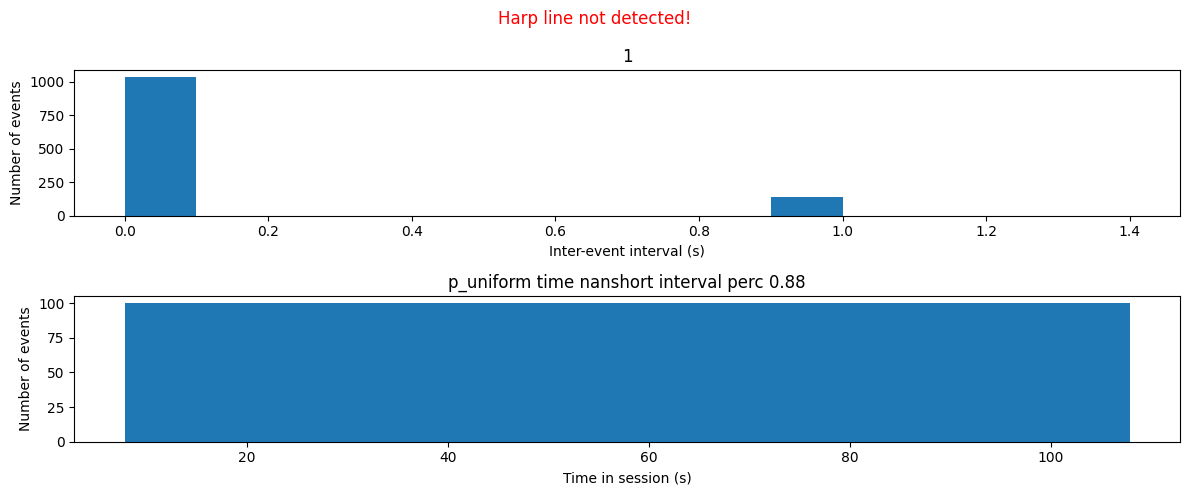

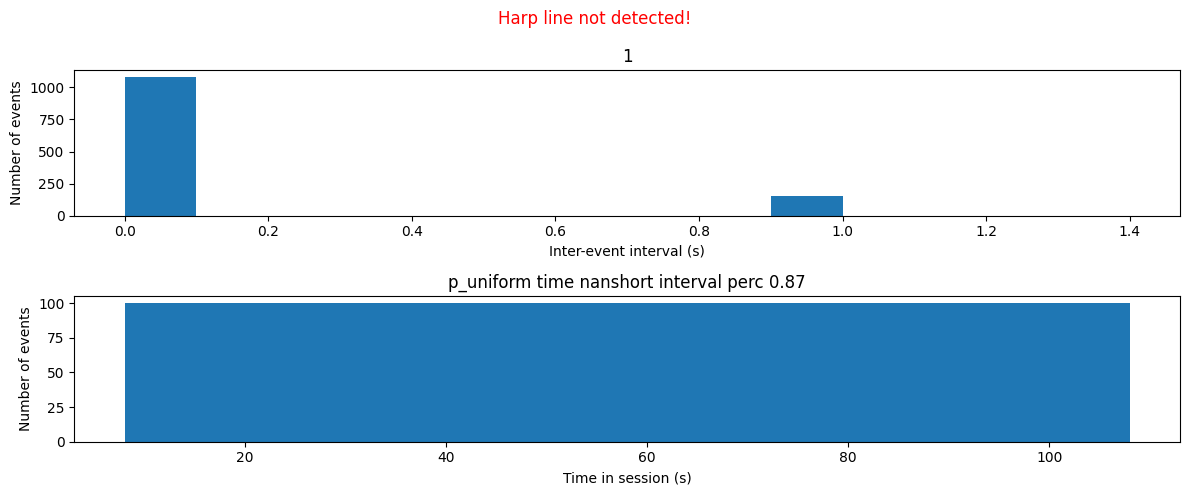

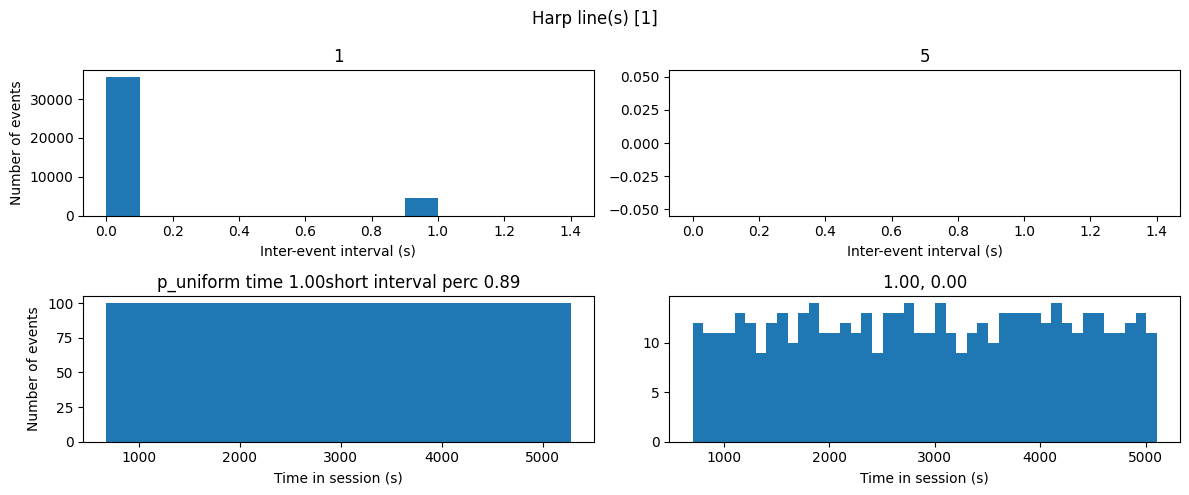

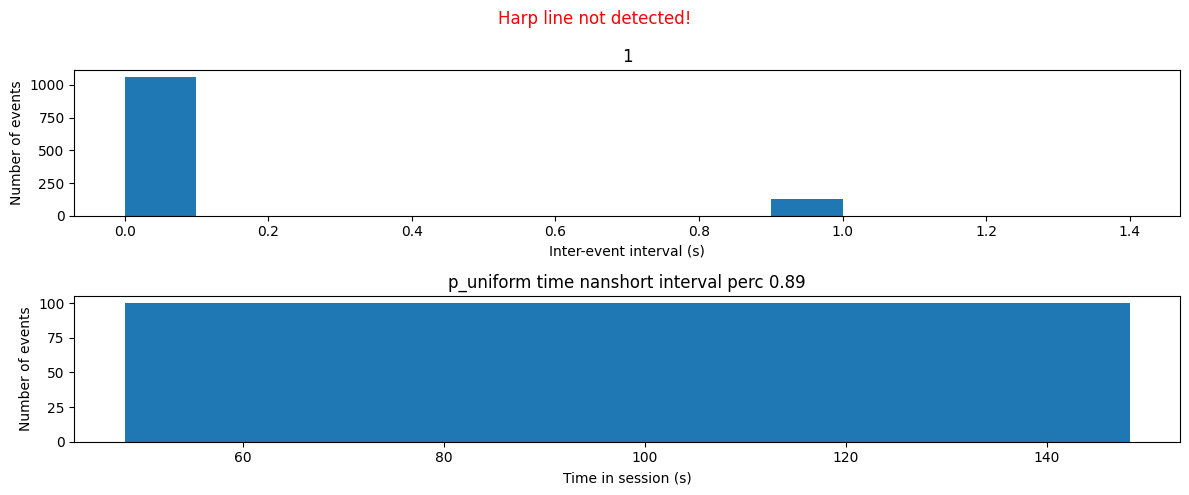

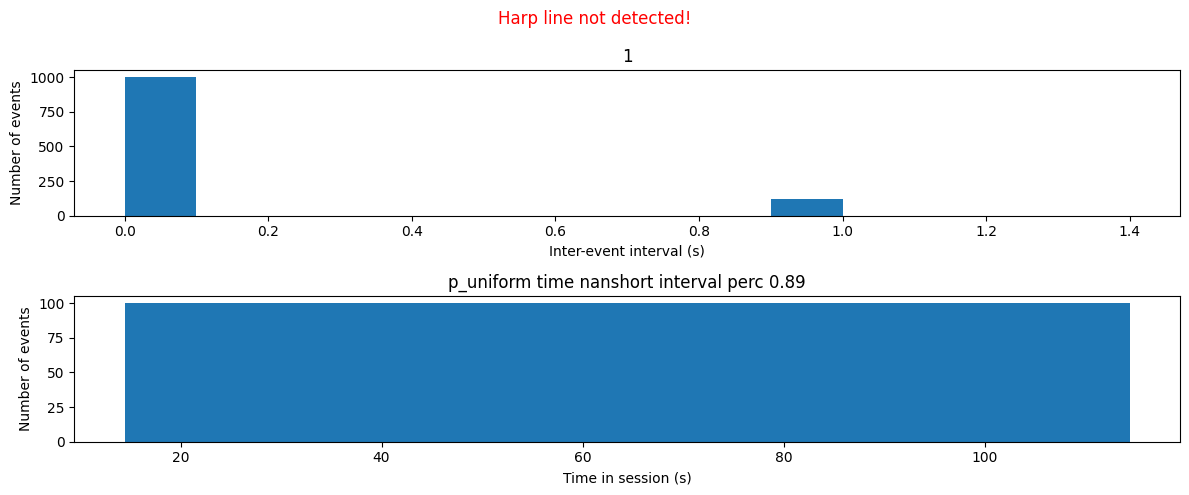

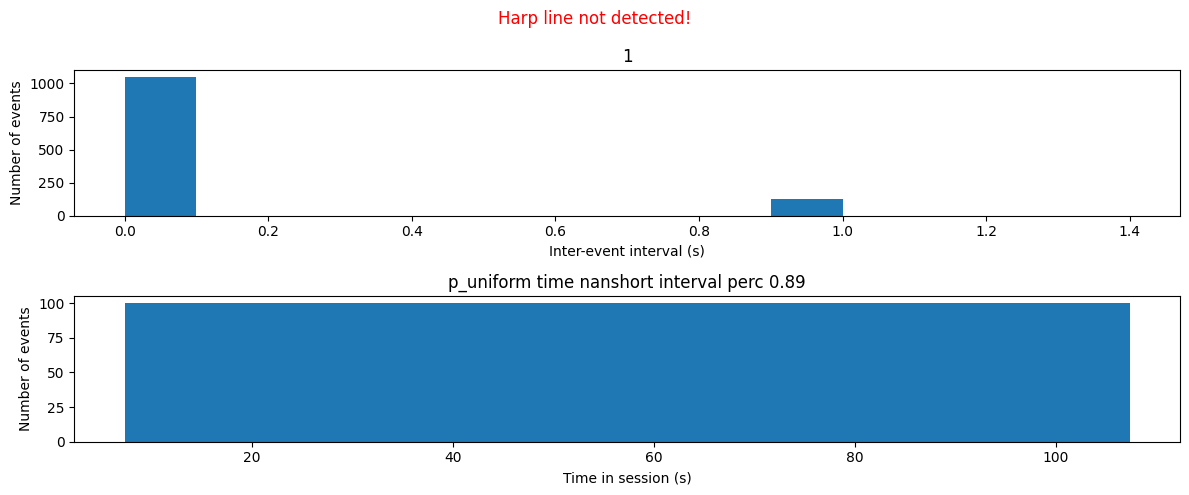

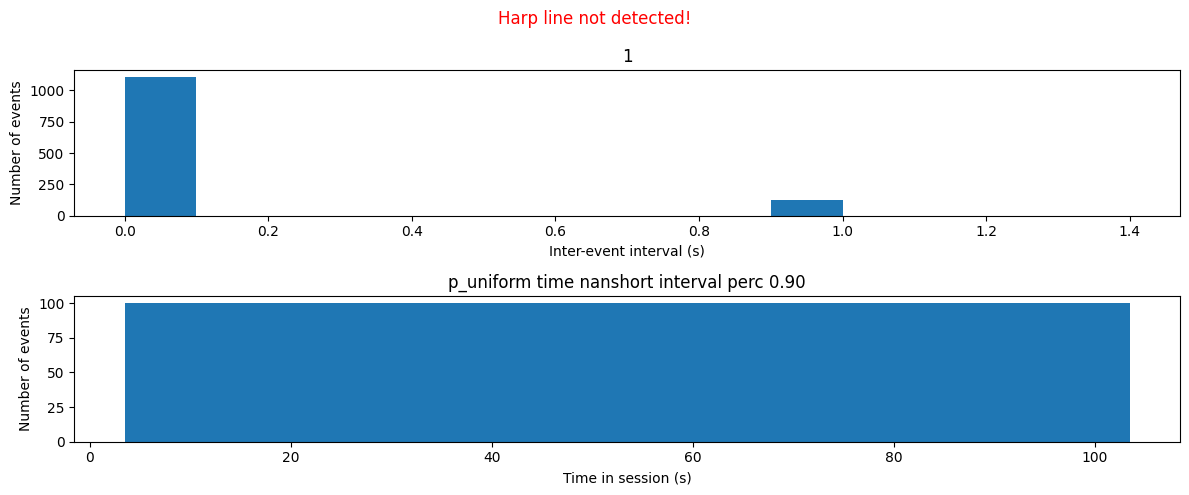

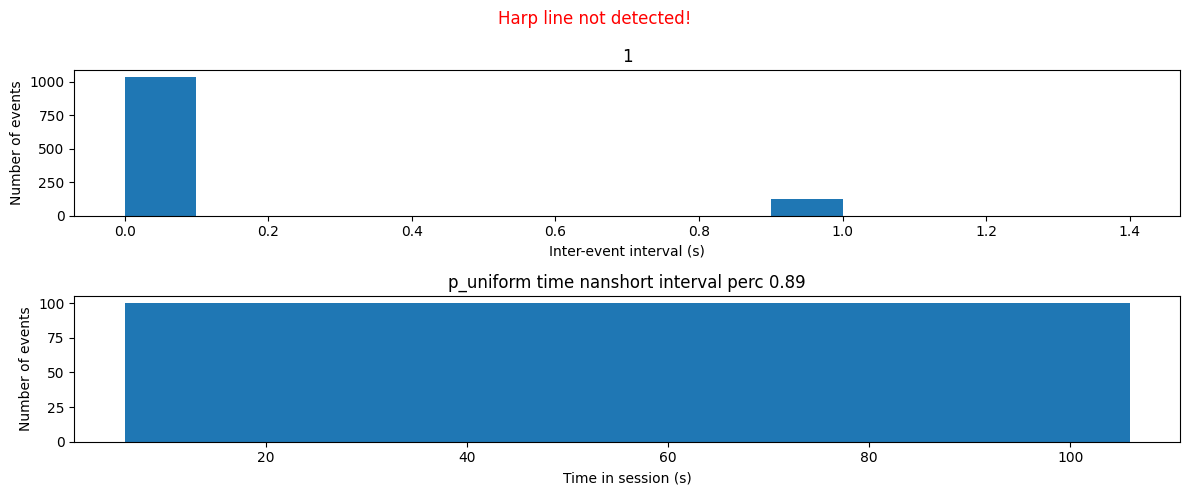

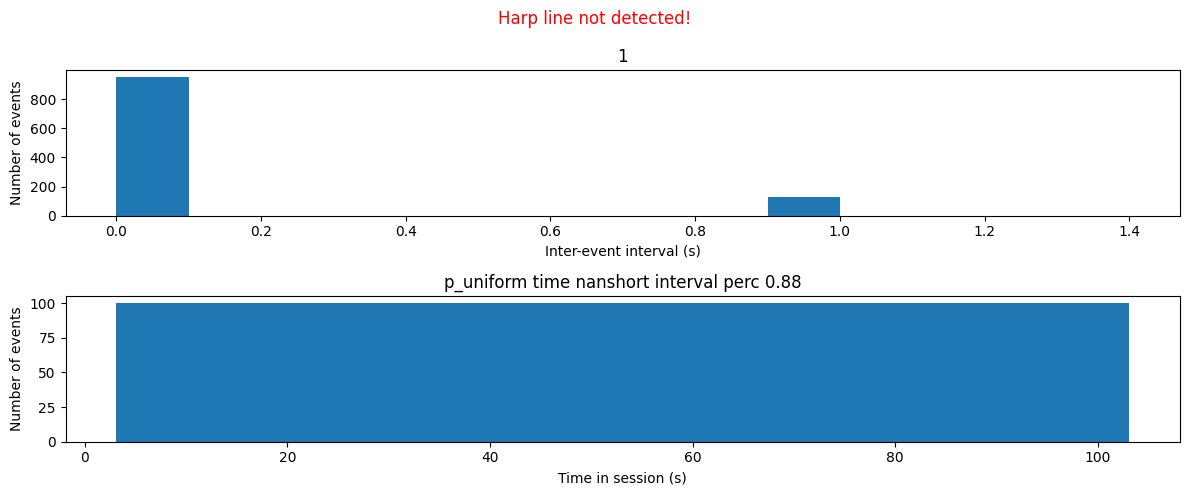

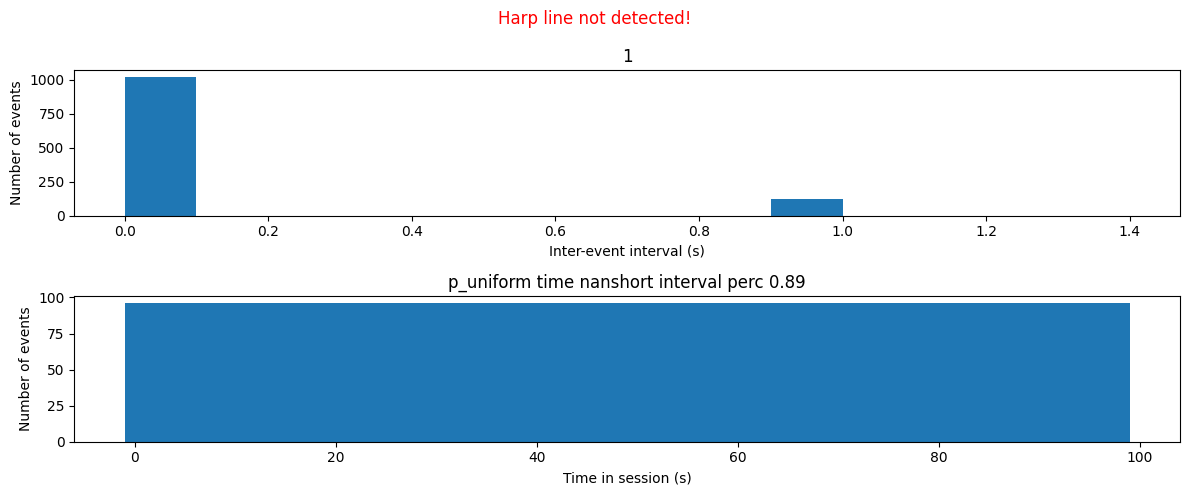

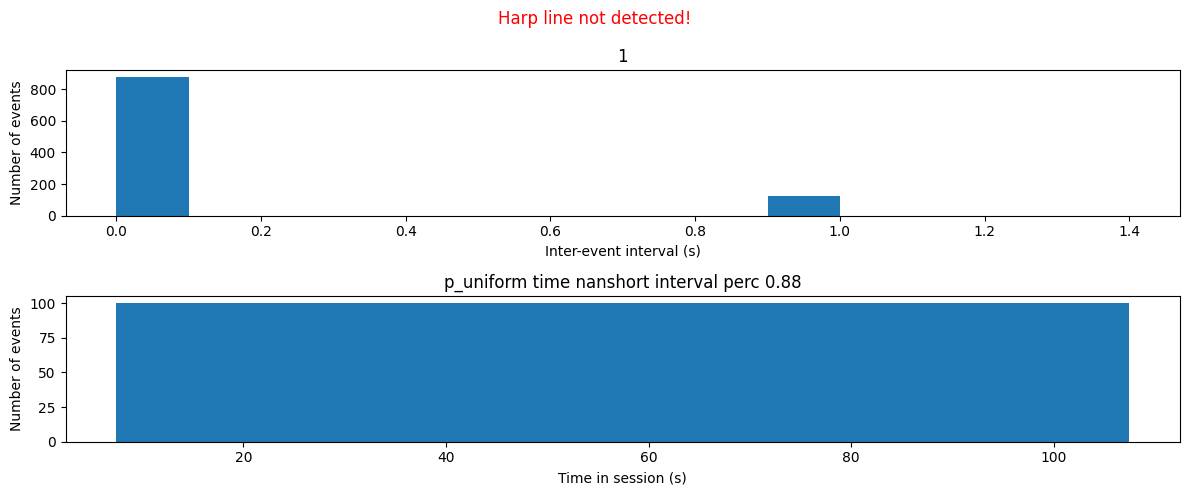

In [1]:
import temporal_alignment as ta
import os
from fpdf import FPDF
#r'X:\753126\753126_2024-10-10_14-41-12',
#r'X:\753126\753126_2024-10-14_11-52-34',
'''
parent_directory_1 = 'X:\\'
parent_directory_2 = 'Z:\ephys\Xinxin\Ephys'
#mouse_ids=['708322','713557','713379','722679','722683','726477','713377','716870','741213','741211']
mouse_ids=['764791','769884']
directories=[]
for mouse_id in mouse_ids:
    try:
        current_directory=os.path.join(parent_directory_1,mouse_id)
        directories=directories+[os.path.join(current_directory,f) for f in os.listdir(current_directory) if f.startswith(mouse_id)]
    except:
        current_directory=os.path.join(parent_directory_2,mouse_id)
        directories=directories+[os.path.join(current_directory,f) for f in os.listdir(current_directory) if f.startswith(mouse_id)]
'''
directories=[r'X:\845710\845710_2026-06-10_12-53-07',r'X:\845710\845710_2026-06-11_12-10-56']
successes=[]
failures=[]
for directory in directories:
    #try:
        pdf1 = FPDF()
        pdf2 = FPDF()

        #ta.align_timestamps(directory=directory, original_timestamp_filename="original_timestamps.npy",
        #    flip_NIDAQ=False,
        #    local_sync_line=1,
        #    main_stream_index=0,
        #    pdf=pdf1)

        ta.align_timestamps_harp(directory=directory,pdf=pdf2)
        successes.append(directory)
   # except:
   #    failures.append(directory)
    #    print(f"Failed for {directory}")


[]

In [ ]:
import numpy as np

original_timestamps_probeA = np.load(r'Z:\ephys_rig_ephys_transfer\323_EPHYS3\753125\753125_2024-10-09_10-50-07\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\original_timestamps.npy')

original_timestamps_probeB = np.load(r'Z:\ephys_rig_ephys_transfer\323_EPHYS3\753125\753125_2024-10-09_10-50-07\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeB\original_timestamps.npy')

timestamps_probeA = np.load(r'Z:\ephys_rig_ephys_transfer\323_EPHYS3\753125\753125_2024-10-09_10-50-07\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\timestamps.npy')

sample_numbers_probeA=np.load(r'Z:\ephys_rig_ephys_transfer\323_EPHYS3\753125\753125_2024-10-09_10-50-07\Record Node 103\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\sample_numbers.npy') 

In [ ]:
timestamps_probeA.shape

In [ ]:
import matplotlib.pyplot as plt

plt.plot(timestamps_probeA, original_timestamps_probeA, 'o')


In [ ]:
original_timestamps_probeA.shape

In [ ]:
timestamps_probeA

In [ ]:
original_timestamps_probeA

In [3]:
import os
import numpy as np

base = r"X:\845710\845710_2026-06-10_12-53-07\Record Node 103\experiment1\recording1\continuous"

streams = {
    "ProbeA": (rf"{base}\Neuropix-PXI-100.ProbeA", 384, 30000.0),
    "ProbeB": (rf"{base}\Neuropix-PXI-100.ProbeB", 384, 30000.0),
    "NIDAQ":  (rf"{base}\NI-DAQmx-102.PXIe-6341", 8, 30000.0),
}

for name, (folder, n_channels, fs) in streams.items():
    ts = np.load(rf"{folder}\timestamps.npy")
    sn = np.load(rf"{folder}\sample_numbers.npy")
    dat_bytes = os.path.getsize(rf"{folder}\continuous.dat")
    dat_samples = dat_bytes // (n_channels * 2)  # int16 = 2 bytes

    print(f"--- {name} ---")
    print(f"  timestamps:    shape={ts.shape}, dtype={ts.dtype}, "
          f"start={ts[0]:.6f}s, end={ts[-1]:.6f}s, "
          f"duration={ts[-1] - ts[0]:.3f}s")
    print(f"  sample_numbers: shape={sn.shape}, dtype={sn.dtype}, "
          f"start={sn[0]}, end={sn[-1]}, span={sn[-1] - sn[0] + 1}")
    print(f"  continuous.dat: {dat_bytes:,} bytes -> "
          f"{dat_samples:,} samples x {n_channels} ch")
    print(f"  expected duration from samples / fs: "
          f"{dat_samples / fs:.3f}s")
    print(f"  lengths match: ts={len(ts)}, sn={len(sn)}, dat={dat_samples} "
          f"-> {len(ts) == len(sn) == dat_samples}")
    print()

--- ProbeA ---
  timestamps:    shape=(138459100,), dtype=float64, start=464.433100s, end=5079.736400s, duration=4615.303s
  sample_numbers: shape=(138459100,), dtype=int64, start=13932993, end=152392092, span=138459100
  continuous.dat: 106,336,588,800 bytes -> 138,459,100 samples x 384 ch
  expected duration from samples / fs: 4615.303s
  lengths match: ts=138459100, sn=138459100, dat=138459100 -> True

--- ProbeB ---
  timestamps:    shape=(138461052,), dtype=float64, start=464.434151s, end=5079.744554s, duration=4615.310s
  sample_numbers: shape=(138461052,), dtype=int64, start=13933191, end=152394242, span=138461052
  continuous.dat: 106,338,087,936 bytes -> 138,461,052 samples x 384 ch
  expected duration from samples / fs: 4615.368s
  lengths match: ts=138461052, sn=138461052, dat=138461052 -> True

--- NIDAQ ---
  timestamps:    shape=(138475988,), dtype=float64, start=464.419075s, end=5079.748654s, duration=4615.330s
  sample_numbers: shape=(138475988,), dtype=int64, start=139